# Lesson 1: Router Engine

Ref: [deeplearning.ai](https://learn.deeplearning.ai/courses/building-agentic-rag-with-llamaindex/lesson/ix5w5/building-an-agent-reasoning-loop)     
Login with email: ashok@fsm.ac.in (password is the usual one)    
   
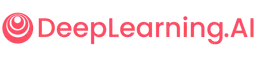

Welcome to Lesson 1.

To access the `requirements.txt` file, the data/pdf file required for this lesson and the `helper` and `utils` modules, please go to the `File` menu and select`Open...`. File `utils.py` is available on github under my llamaindex folder

I hope you enjoy this course!

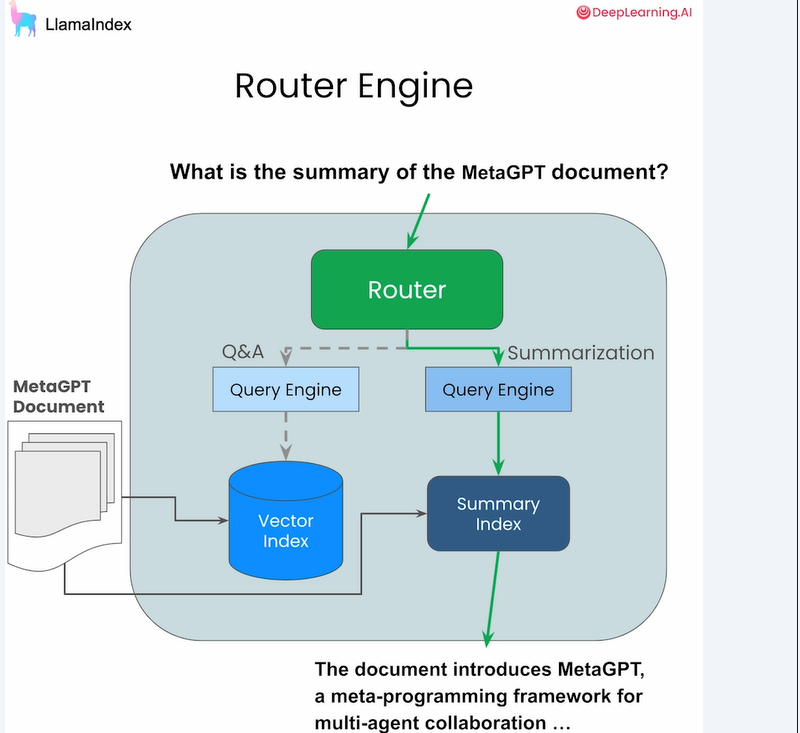

Note that Router is usable with QueryEngineTools and NOT with FunctionTools

## Setup

### Why nest_asyncio?

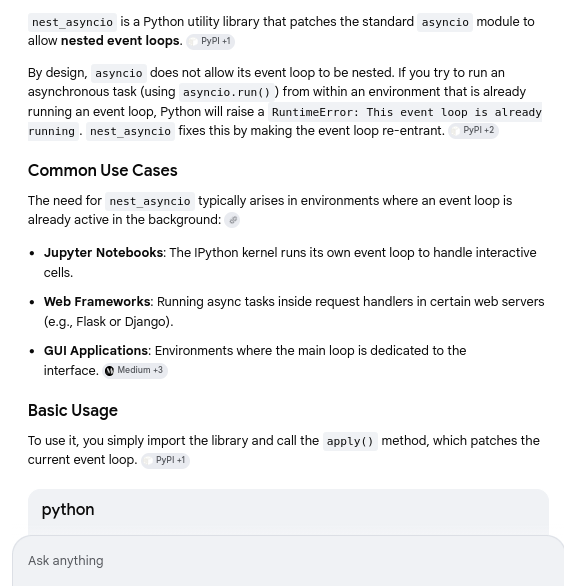

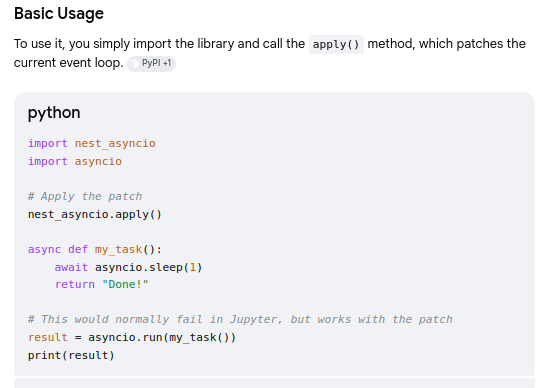

In [107]:
%reset

import nest_asyncio

nest_asyncio.apply()

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


## Load Data

To download this paper, below is the needed code:

#!wget "https://openreview.net/pdf?id=VtmBAGCN7o" -O metagpt.pdf

**Note**: The pdf file is included with this lesson. To access it, go to the `File` menu and select`Open...`.

In [2]:
!wget "https://openreview.net/pdf?id=VtmBAGCN7o" -O /home/ashok/Documents/csvrag/metagpt.pdf

--2025-03-20 06:26:47--  https://openreview.net/pdf?id=VtmBAGCN7o
Resolving openreview.net (openreview.net)... 35.184.86.251
connected. to openreview.net (openreview.net)|35.184.86.251|:443... 
HTTP request sent, awaiting response... 200 OK
Length: 16911937 (16M) [application/pdf]
Saving to: ‘/home/ashok/Documents/metagpt.pdf’

/home/ashok/Documen 100%[===================>]  16.13M  4.04MB/s    in 5.7s    

2025-03-20 06:26:54 (2.85 MB/s) - ‘/home/ashok/Documents/metagpt.pdf’ saved [16911937/16911937]



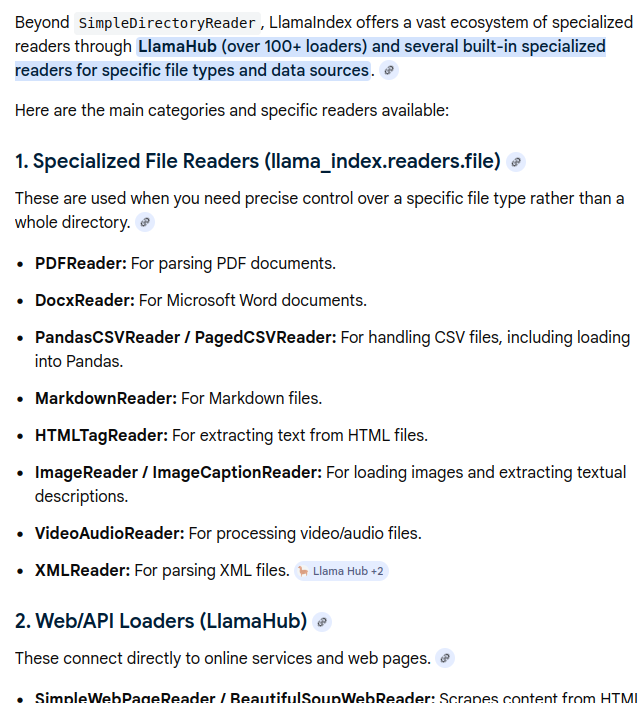

In [136]:
# Ollama related
# https://docs.llamaindex.ai/en/stable/examples/embeddings/ollama_embedding/
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.llms.ollama import Ollama
from llama_index.core import SimpleDirectoryReader

# load documents
pathToFiles = ["/home/ashok/Documents/llamaindex/deeplearning_course/sports.pdf"]
documents = SimpleDirectoryReader(input_files= pathToFiles).load_data()

## Define LLM and Embedding model

In [137]:
from llama_index.core.node_parser import SentenceSplitter

splitter = SentenceSplitter(chunk_size=1024)
nodes = splitter.get_nodes_from_documents(documents)

In [110]:
len(nodes) # Number of chunks

4

In [148]:
from llama_index.core import Settings

llm = Ollama(
                 model=  "deepseek-r1:7b", #  works best for router agent, # "qwen3.5:4b", #      "llama3.2:latest",
                 request_timeout=3600,  # Change it
                 #temperature = 0.4,
                 context_window=4096,    # Limit timeouts
                 #mirostat = 0
            )

embed_model = OllamaEmbedding(
                              model_name="nomic-embed-text",      # Using foundational model may be overkill
                              base_url="http://localhost:11434",
                             )

In [143]:
Settings.llm = llm
Settings.embed_model = embed_model

## Define Summary Index and Vector Index over the Same Data

In [112]:
from llama_index.core import SummaryIndex, VectorStoreIndex

summary_index = SummaryIndex(nodes)
vector_index = VectorStoreIndex(
                                 nodes,
                                 show_progres = True
                               )

2026-04-13 13:36:35,905 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"


## Define Query Engines and Set Metadata

### ToDo: Try chat engine instead of `as_query_engine()`
See [here](https://docs.llamaindex.ai/en/stable/module_guides/deploying/chat_engines/)     
Check whether chat method is possible

In [113]:
summary_query_engine = summary_index.as_query_engine(
                                                     response_mode="tree_summarize",
                                                     use_async= False,   # use_async= True,  # Optional but gives faster response
                                                    )

vector_query_engine = vector_index.as_query_engine(show_progress = True)


In [114]:
from llama_index.core.tools import QueryEngineTool


summary_tool = QueryEngineTool.from_defaults(
                                             query_engine=summary_query_engine,
                                             description=(
                                                          "Useful for summarization questions related to Sports"
                                                          ),
                                              )

vector_tool = QueryEngineTool.from_defaults(
                                             query_engine=vector_query_engine,
                                             #similarity_top_k=3,
                                             description=(
                                                           "Useful for retrieving specific context from the sports paper."
                                                         ),
                                            )

### What is tree_summarize

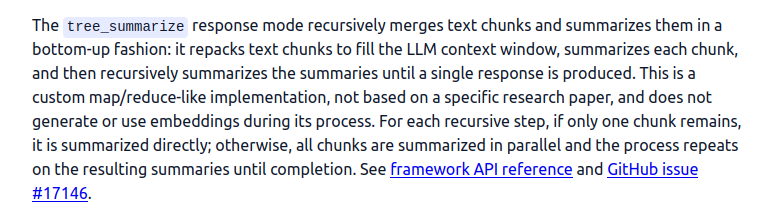

## Define Router Query Engine
Here is our router

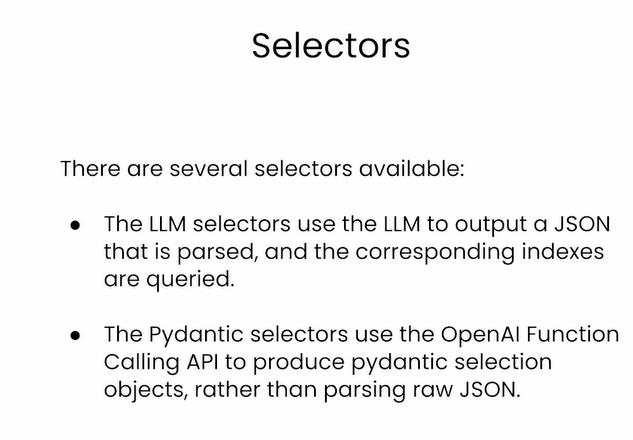

The first selector returns a JSON object, the second one retuns a string and not raw json.

In [115]:
from llama_index.core.query_engine.router_query_engine import RouterQueryEngine
from llama_index.core.selectors import LLMSingleSelector

# Router takes two arguments:
#                              Which router
#                              NAmes of Query engine tools

query_engine = RouterQueryEngine(
                                 selector=LLMSingleSelector.from_defaults(),
                                 query_engine_tools=[
                                                        summary_tool,    # 0
                                                        vector_tool,     # 1
                                                    ],
                                 verbose=True
                               )

In [116]:
%%time

response = query_engine.query("What is the summary of the document?")
print(str(response))

2026-04-13 13:37:07,104 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
2026-04-13 13:37:07,105 - INFO - Selecting query engine 0: The question is asking for a summary, which typically relates to summarization questions related to sports..


Selecting query engine 0: The question is asking for a summary, which typically relates to summarization questions related to sports..


2026-04-13 13:38:23,996 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


The document discusses the dual impact of physical activity and sports on health, highlighting both positive effects, such as improved mental well-being and reduced disease risks, and negative risks like obesity and stress-related issues. It emphasizes that increasing physical activity is beneficial for public health in Sweden but notes that balancing it with proper diet is crucial to avoid negative outcomes. The study concludes that meeting daily recommendations for physical activity can improve health across all age groups, though individual factors such as genetics and environment influence adaptation levels.
CPU times: user 23 ms, sys: 1.04 ms, total: 24.1 ms
Wall time: 1min 38s


### How do selectors work?

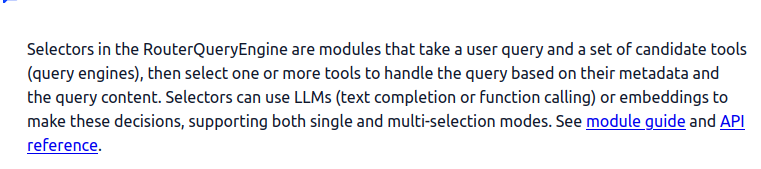

#### How do selectors use embeddings to make a selection decision?

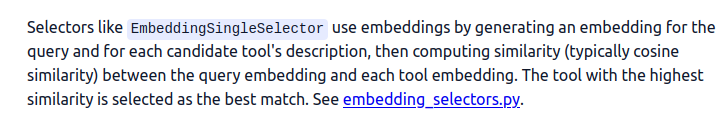

In [117]:
print(len(response.source_nodes))

4


### ToDo: Try chat engibe instead of query engine.
See [here](https://docs.llamaindex.ai/en/stable/module_guides/deploying/chat_engines/)     
Check whether chat method is possible

In [118]:
%%time

response = query_engine.query(
                              "Why is sports a double edged sword?"
                             )
print(str(response))

2026-04-13 13:39:21,052 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
2026-04-13 13:39:21,052 - INFO - Selecting query engine 1: The question asks for specific reasons related to why sports is a double-edged sword. Choice (1) only handles summarization, which may not provide the necessary details. Choice (2), retrieving context from a sports paper, allows for detailed analysis of the various aspects contributing to both benefits and drawbacks..


Selecting query engine 1: The question asks for specific reasons related to why sports is a double-edged sword. Choice (1) only handles summarization, which may not provide the necessary details. Choice (2), retrieving context from a sports paper, allows for detailed analysis of the various aspects contributing to both benefits and drawbacks..


2026-04-13 13:39:22,213 - INFO - HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
2026-04-13 13:40:08,341 - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


Sports are considered a double-edged sword because they offer both positive and negative effects on health. On the positive side, physical activity through sports helps prevent or alleviate mental health issues such as depression and anxiety. They also contribute to overall well-being and can improve quality of life across different age groups and sexes. However, sports can lead to negative consequences, including stress-related problems like burnout, injuries, and mental health issues due to factors such as failed performances, recovery challenges, or physical strain. Therefore, while beneficial when approached responsibly, sports require careful management to avoid these risks.

Answer: Sports are a double-edged sword because they provide significant health benefits, such as improving mental and physical well-being, but also pose risks like injuries, burnout, and stress-related issues if not managed carefully.


## Let's put everything together

In [27]:
#from utils import get_router_query_engine

from llama_index.core import SimpleDirectoryReader
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core import Settings
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.llms.ollama import Ollama
from llama_index.core import SummaryIndex, VectorStoreIndex
from llama_index.core.tools import QueryEngineTool
from llama_index.core.query_engine.router_query_engine import RouterQueryEngine
from llama_index.core.selectors import LLMSingleSelector




def get_router_query_engine(file_path: str, llm = None, embed_model = None):
    """Get router query engine."""
    llm = Settings.llm = Ollama(
                        model="llama3.2:latest",
                        request_timeout=120.0,
                        temperature = 0.0,
                        mirostat = 0)

    embed_model = OllamaEmbedding( 
                                    model_name="nomic-embed-text",      # Using foundational model may be overkill
                                    base_url="http://localhost:11434",
                                       )
        
    # load documents
    documents = SimpleDirectoryReader(input_files=[file_path]).load_data()
    
    splitter = SentenceSplitter(chunk_size=1024)
    nodes = splitter.get_nodes_from_documents(documents)
    
    summary_index = SummaryIndex(nodes)
    vector_index = VectorStoreIndex(nodes, embed_model=embed_model)
    
    summary_query_engine = summary_index.as_query_engine(
        response_mode="tree_summarize",
        use_async=True,  # Optional but gives faster response
        llm=llm
    )
    vector_query_engine = vector_index.as_query_engine(llm=llm)
    
    summary_tool = QueryEngineTool.from_defaults(
        query_engine=summary_query_engine,
        description=(
            "Useful for summarization questions related to MetaGPT"
        ),
    )
    
    vector_tool = QueryEngineTool.from_defaults(
        query_engine=vector_query_engine,
        description=(
            "Useful for retrieving specific context from the MetaGPT paper."
        ),
    )
    
    query_engine = RouterQueryEngine(
        selector=LLMSingleSelector.from_defaults(),
        query_engine_tools=[
            summary_tool,
            vector_tool,
        ],
        verbose=True
    )
    return query_engine

query_engine = get_router_query_engine("metagpt.pdf")  




In [28]:
response = query_engine.query("Tell me about the ablation study results?")
print(str(response))

Selecting query engine 1: The ablation study results are likely to be discussed in the context of the MetaGPT paper, making option (2) the most relevant choice..
The MetaGPT model outperforms all preceding approaches in both HumanEval and MBPP benchmarks. When collaborating with GPT-4, it significantly improves Pass @k in the HumanEval benchmark. The collaboration achieves 85.9% and 87.7%.
